In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer, KNNImputer
import warnings

In [3]:
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
sns.set_palette("husl")

COL_NAMES = ["duration","protocol_type","service","flag","src_bytes",
    "dst_bytes","land","wrong_fragment","urgent","hot","num_failed_logins",
    "logged_in","num_compromised","root_shell","su_attempted","num_root",
    "num_file_creations","num_shells","num_access_files","num_outbound_cmds",
    "is_host_login","is_guest_login","count","srv_count","serror_rate",
    "srv_serror_rate","rerror_rate","srv_rerror_rate","same_srv_rate",
    "diff_srv_rate","srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate","label", "difficulty_level"]

In [6]:
train_path = r"C:\Users\Admin\data\KDDTrain+.txt"
test_path  = r"C:\Users\Admin\data\KDDTest+.txt"

try:
    df_train = pd.read_csv(train_path, header=None, names=COL_NAMES)
    df_test = pd.read_csv(test_path, header=None, names=COL_NAMES)
    print(f"Training Data Shape: {df_train.head()}")
    print(f"Test Data Shape: {df_test.tail()}")
except FileNotFoundError:
    print("Files not found. Please check the paths. Trying absolute paths or checking local directory...")

    if os.path.exists('KDDTrain+.txt'):
        df_train = pd.read_csv('KDDTrain+.txt', header=None, names=COL_NAMES)
        df_test = pd.read_csv('KDDTest+.txt', header=None, names=COL_NAMES)

Training Data Shape:    duration protocol_type   service flag  src_bytes  dst_bytes  land  \
0         0           tcp  ftp_data   SF        491          0     0   
1         0           udp     other   SF        146          0     0   
2         0           tcp   private   S0          0          0     0   
3         0           tcp      http   SF        232       8153     0   
4         0           tcp      http   SF        199        420     0   

   wrong_fragment  urgent  hot  ...  dst_host_same_srv_rate  \
0               0       0    0  ...                    0.17   
1               0       0    0  ...                    0.00   
2               0       0    0  ...                    0.10   
3               0       0    0  ...                    1.00   
4               0       0    0  ...                    1.00   

   dst_host_diff_srv_rate  dst_host_same_src_port_rate  \
0                    0.03                         0.17   
1                    0.60                         0

In [7]:
# Clean label column (very important)
df_train['label'] = df_train['label'].str.strip()
df_test['label'] = df_test['label'].str.strip()

attack_mapping = {
    'normal': 'normal',
    
    # DoS
    'back': 'DoS', 'land': 'DoS', 'neptune': 'DoS', 'pod': 'DoS',
    'smurf': 'DoS', 'teardrop': 'DoS', 'mailbomb': 'DoS',
    'apache2': 'DoS', 'processtable': 'DoS', 'udpstorm': 'DoS',
    
    # Probe
    'satan': 'Probe', 'ipsweep': 'Probe', 'nmap': 'Probe',
    'portsweep': 'Probe', 'mscan': 'Probe', 'saint': 'Probe',
    
    # R2L
    'guess_passwd': 'R2L', 'ftp_write': 'R2L', 'imap': 'R2L',
    'phf': 'R2L', 'multihop': 'R2L', 'warezmaster': 'R2L',
    'warezclient': 'R2L', 'spy': 'R2L', 'xlock': 'R2L',
    'xsnoop': 'R2L', 'snmpguess': 'R2L',
    'snmpgetattack': 'R2L', 'httptunnel': 'R2L',
    'sendmail': 'R2L', 'named': 'R2L',
    
    # U2R
    'buffer_overflow': 'U2R', 'loadmodule': 'U2R',
    'perl': 'U2R', 'rootkit': 'U2R',
    'ps': 'U2R', 'xterm': 'U2R', 'sqlattack': 'U2R'
}

# Apply mapping safely
df_train['attack_class'] = df_train['label'].map(attack_mapping).fillna('other')
df_test['attack_class'] = df_test['label'].map(attack_mapping).fillna('other')

print("Training Class Distribution:")
print(df_train['attack_class'].value_counts())

print("\nTest Class Distribution:")
print(df_test['attack_class'].value_counts())

Training Class Distribution:
attack_class
normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64

Test Class Distribution:
attack_class
normal    9711
DoS       7458
R2L       2885
Probe     2421
U2R         67
other        2
Name: count, dtype: int64


In [8]:
# Feature categorization

categorical_features = ['protocol_type', 'service', 'flag']
binary_features = ['land', 'logged_in', 'is_host_login', 'is_guest_login']

# All remaining numerical features
numerical_features = [
    col for col in COL_NAMES 
    if col not in categorical_features + binary_features + ['label', 'difficulty']
]

print(f"Categorical Features: {len(categorical_features)}")
print(f"Binary Features: {len(binary_features)}")
print(f"Numerical Features: {len(numerical_features)}")

# Check missing values properly
print("\nMissing Values in Training Data:")
print(df_train.isnull().sum())

Categorical Features: 3
Binary Features: 4
Numerical Features: 35

Missing Values in Training Data:
duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
num_compromised                0
root_shell                     0
su_attempted                   0
num_root                       0
num_file_creations             0
num_shells                     0
num_access_files               0
num_outbound_cmds              0
is_host_login                  0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerro

In [9]:
from sklearn.ensemble import IsolationForest

def clean_outliers_isolation_forest(df, contamination=0.01):
    
    # Select only numerical features
    iso_df = df[numerical_features].copy()
    
    # Initialize Isolation Forest
    clf = IsolationForest(
        max_samples='auto',
        contamination=contamination,
        random_state=42,
        n_jobs=-1
    )
    
    # Fit and predict
    outliers = clf.fit_predict(iso_df)
    
    n_outliers = (outliers == -1).sum()
    print(f"Identified {n_outliers} outliers using Isolation Forest")
    
    return outliers


# Apply to training data
df_train['is_outlier'] = clean_outliers_isolation_forest(df_train)

# Check distribution
print(df_train['is_outlier'].value_counts())

Identified 1260 outliers using Isolation Forest
is_outlier
 1    124713
-1      1260
Name: count, dtype: int64


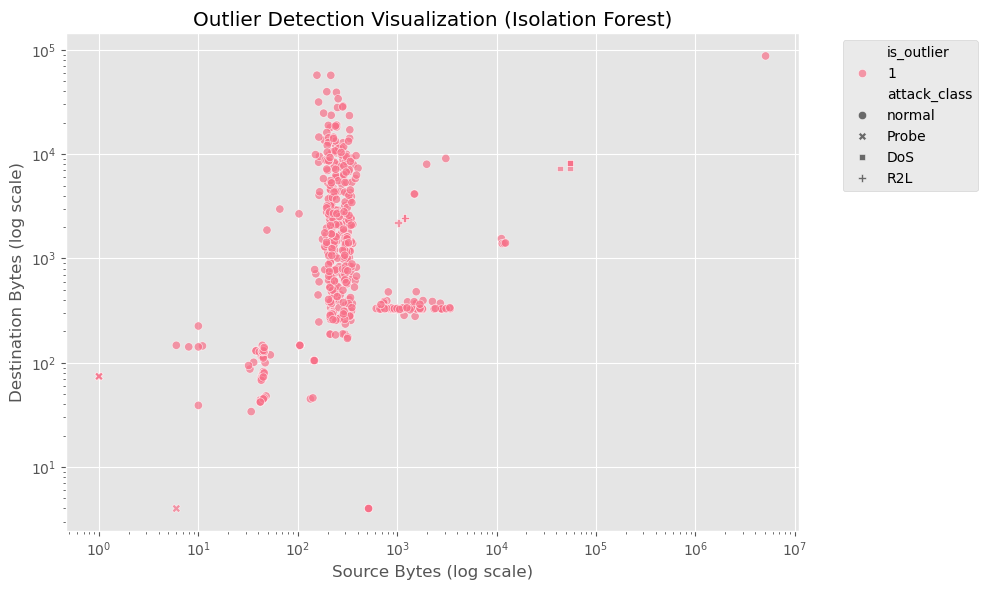

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Remove zero or negative values for log scale safety
plot_df = df_train[(df_train['src_bytes'] > 0) & 
                   (df_train['dst_bytes'] > 0)].copy()

# Reduce data for faster plotting
plot_df = plot_df.iloc[::100]

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=plot_df,
    x='src_bytes',
    y='dst_bytes',
    hue='is_outlier',
    style='attack_class',
    alpha=0.7
)

plt.xscale('log')
plt.yscale('log')

plt.title("Outlier Detection Visualization (Isolation Forest)")
plt.xlabel("Source Bytes (log scale)")
plt.ylabel("Destination Bytes (log scale)")

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

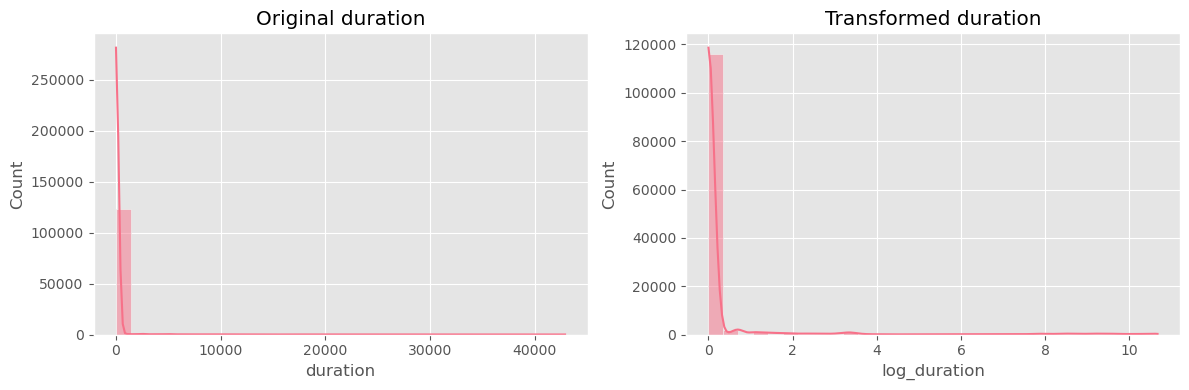

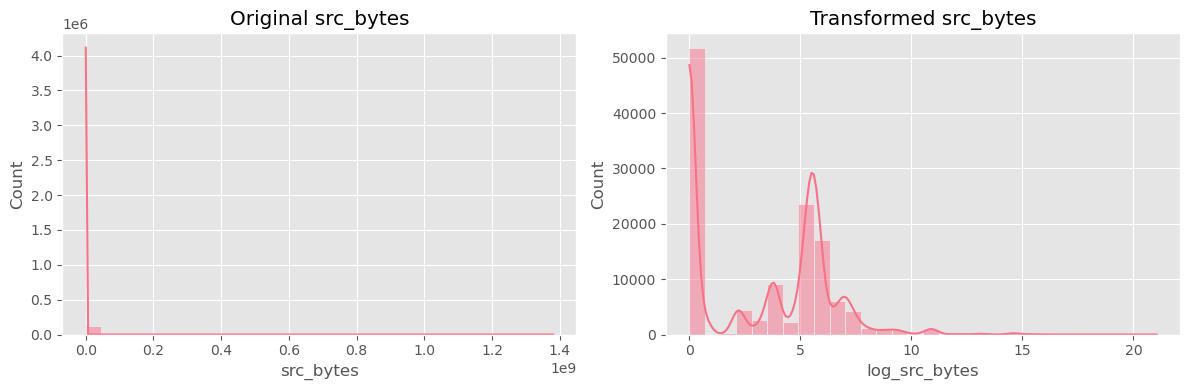

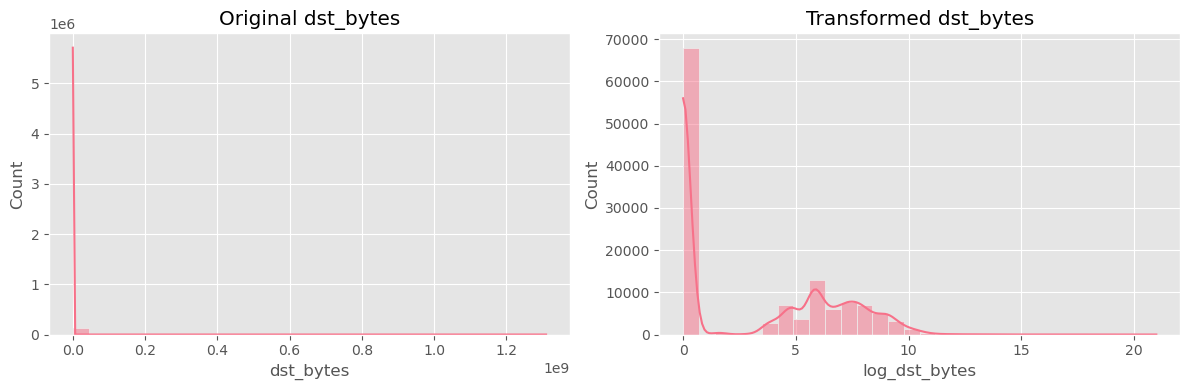

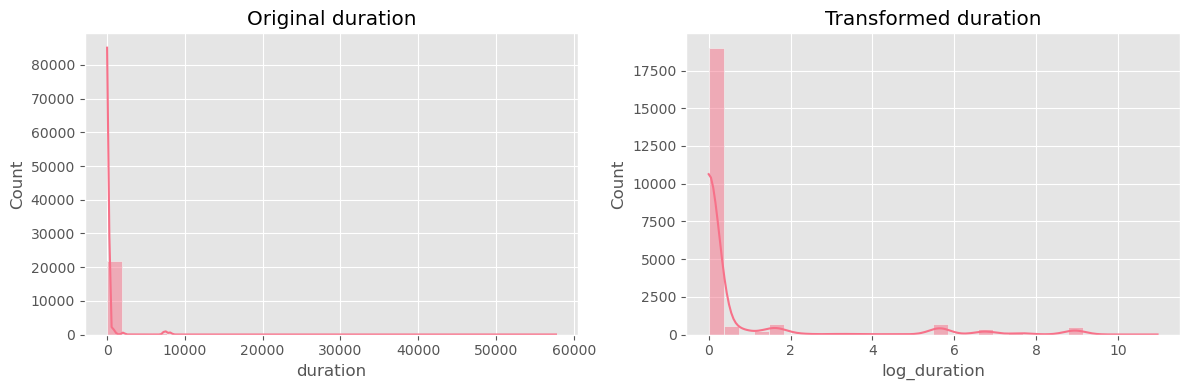

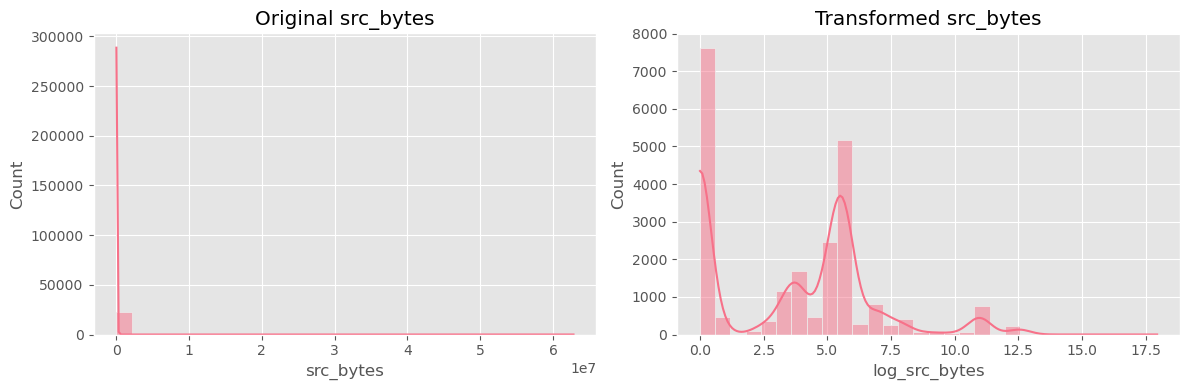

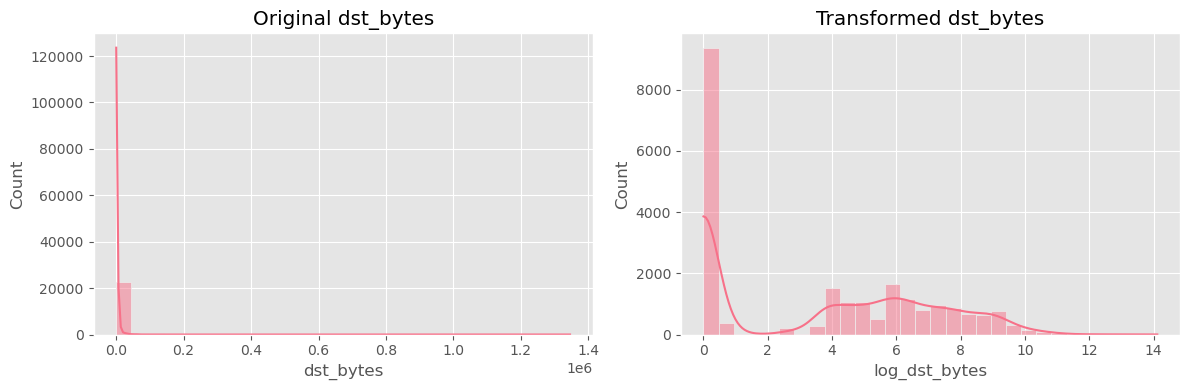

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

skewed_cols = ['duration', 'src_bytes', 'dst_bytes']

# Function for Log1p transformation (log(x+1)) to handle zeros
def apply_log_transform(df, cols):
    
    df_transform = df.copy()
    
    for col in cols:
        
        # Creating a new column name
        new_col = f"log_{col}"
        
        # Applying logarithmic transformation
        df_transform[new_col] = np.log1p(df_transform[col])
        
        # Plot comparison
        plt.figure(figsize=(12, 4))
        
        plt.subplot(1, 2, 1)
        sns.histplot(df_transform[col], bins=30, kde=True)
        plt.title(f"Original {col}")
        
        plt.subplot(1, 2, 2)
        sns.histplot(df_transform[new_col], bins=30, kde=True)
        plt.title(f"Transformed {col}")
        
        plt.tight_layout()
        plt.show()
    
    return df_transform


# Apply transformation
df_train = apply_log_transform(df_train, skewed_cols)
df_test = apply_log_transform(df_test, skewed_cols)

In [12]:
import numpy as np

def engineer_features(df):
    
    df_eng = df.copy()
    
    # Safety check (optional but professional)
    required_cols = ['src_bytes', 'dst_bytes', 'count', 'duration',
                     'flag', 'same_srv_rate', 'dst_host_same_srv_rate']
    
    missing_cols = [col for col in required_cols if col not in df_eng.columns]
    if missing_cols:
        print(f"Missing columns: {missing_cols}")
        return df_eng

    df_eng['total_bytes'] = df_eng['src_bytes'] + df_eng['dst_bytes']

    df_eng['src_bytes_ratio'] = (
        df_eng['src_bytes'] / (df_eng['total_bytes'] + 1e-5)
    )
    
    df_eng['packet_rate'] = (
        df_eng['count'] / (df_eng['duration'] + 1e-5)
    )
    
   
    df_eng['byte_diff'] = np.abs(
        df_eng['src_bytes'] - df_eng['dst_bytes']
    )
 
    error_flags = ['S0', 'S1', 'S2', 'S3', 'REJ']
    df_eng['is_error_flag'] = (
        df_eng['flag'].isin(error_flags).astype(int)
    )
    

    df_eng['same_srv_interaction'] = (
        df_eng['same_srv_rate'] *
        df_eng['dst_host_same_srv_rate']
    )
    
    return df_eng

df_train = engineer_features(df_train)
df_test = engineer_features(df_test)

print("New Feature Set Head:")
print(df_train[['src_bytes_ratio',
                'packet_rate',
                'is_error_flag',
                'same_srv_interaction']].head())

New Feature Set Head:
   src_bytes_ratio  packet_rate  is_error_flag  same_srv_interaction
0         1.000000     200000.0              0                 0.170
1         1.000000    1300000.0              0                 0.000
2         0.000000   12300000.0              1                 0.005
3         0.027668     500000.0              0                 1.000
4         0.321486    3000000.0              0                 1.000


In [13]:
df_train['service']

0         ftp_data
1            other
2          private
3             http
4             http
            ...   
125968     private
125969     private
125970        smtp
125971      klogin
125972    ftp_data
Name: service, Length: 125973, dtype: object

In [14]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

cols_to_encode = ['protocol_type', 'flag']

ohe_train = pd.DataFrame(
    ohe.fit_transform(df_train[cols_to_encode]),
    columns=ohe.get_feature_names_out(cols_to_encode),
    index=df_train.index
)

ohe_test = pd.DataFrame(
    ohe.transform(df_test[cols_to_encode]),
    columns=ohe.get_feature_names_out(cols_to_encode),
    index=df_test.index
)

service_freq = df_train['service'].value_counts(normalize=True)

df_train['service_freq'] = df_train['service'].map(service_freq)
df_test['service_freq'] = df_test['service'].map(service_freq).fillna(0)

df_train_encode = pd.concat([df_train.drop(columns=cols_to_encode), ohe_train], axis=1)
df_test_encode = pd.concat([df_test.drop(columns=cols_to_encode), ohe_test], axis=1)

df_train_encode.columns

Index(['duration', 'service', 'src_bytes', 'dst_bytes', 'land',
       'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in',
       'num_compromised', 'root_shell', 'su_attempted', 'num_root',
       'num_file_creations', 'num_shells', 'num_access_files',
       'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count',
       'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate',
       'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate',
       'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
       'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
       'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate',
       'dst_host_serror_rate', 'dst_host_srv_serror_rate',
       'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label',
       'difficulty_level', 'attack_class', 'is_outlier', 'log_duration',
       'log_src_bytes', 'log_dst_bytes', 'total_bytes', 'src_bytes_ratio',
       'packet_rate', 'byte_diff', 'is_error_flag', 'sam

In [15]:
df_test_encode

,duration,service,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,...,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
0,0,private,0,0,0,0,0,0,0,0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,private,0,0,0,0,0,0,0,0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,ftp_data,12983,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0,eco_i,20,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,1,telnet,0,15,0,0,0,0,0,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22539,0,smtp,794,333,0,0,0,0,0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
22540,0,http,317,938,0,0,0,0,0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
22541,0,http,54540,8314,0,0,0,2,0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
22542,0,domain_u,42,42,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [16]:
print("Train Shape:", df_train_encode.shape)
print("Test Shape:", df_test_encode.shape)

df_test_encode.head()

Train Shape: (125973, 67)
Test Shape: (22544, 66)


,duration,service,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,...,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
0,0,private,0,0,0,0,0,0,0,0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,private,0,0,0,0,0,0,0,0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,ftp_data,12983,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0,eco_i,20,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,1,telnet,0,15,0,0,0,0,0,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [17]:
import numpy as np

corr_matrix = df_train_encode.select_dtypes(include=[np.number]).corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]

print("Features to drop due to high correlation (>0.95):", to_drop)

df_train_reduce = df_train_encode.drop(columns=to_drop)

cols_dropped_from_test = [c for c in to_drop if c in df_test_encode.columns]
df_test_reduce = df_test_encode.drop(columns=cols_dropped_from_test)

print("Reduced Train Shape:", df_train_reduce.shape)
print("Reduced Test Shape:", df_test_reduce.shape)

Features to drop due to high correlation (>0.95): ['num_root', 'srv_serror_rate', 'srv_rerror_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_srv_rerror_rate', 'packet_rate', 'byte_diff', 'same_srv_interaction', 'flag_S0']
Reduced Train Shape: (125973, 57)
Reduced Test Shape: (22544, 56)


In [23]:
from sklearn.preprocessing import RobustScaler

exclude_cols = ['label', 'attack_class']

train_numeric = df_train_reduce.select_dtypes(include=['int64', 'float64']).drop(columns=exclude_cols, errors='ignore')
test_numeric = df_test_reduce.select_dtypes(include=['int64', 'float64']).drop(columns=exclude_cols, errors='ignore')

common_cols = train_numeric.columns.intersection(test_numeric.columns)

scaler = RobustScaler()

df_train_reduce[common_cols] = scaler.fit_transform(train_numeric[common_cols])
df_test_reduce[common_cols] = scaler.transform(test_numeric[common_cols])

print("Scaling completed successfully")

Scaling completed successfully


In [24]:
from imblearn.over_sampling import SMOTE

target_col = 'attack_class'

X = df_train_reduce.drop(columns=[target_col], errors='ignore')
y = df_train_reduce[target_col]

X = X.select_dtypes(include=['int64', 'float64'])
X = X.fillna(0)

print("Before SMOTE:")
print(y.value_counts())

smote = SMOTE(k_neighbors=5, random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("\nAfter SMOTE:")
print(y_resampled.value_counts())

y_resampled                                                                                

Before SMOTE:
attack_class
normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64

After SMOTE:
attack_class
normal    67343
DoS       67343
R2L       67343
Probe     67343
U2R       67343
Name: count, dtype: int64


0         normal
1         normal
2            DoS
3         normal
4         normal
           ...  
336710       U2R
336711       U2R
336712       U2R
336713       U2R
336714       U2R
Name: attack_class, Length: 336715, dtype: object

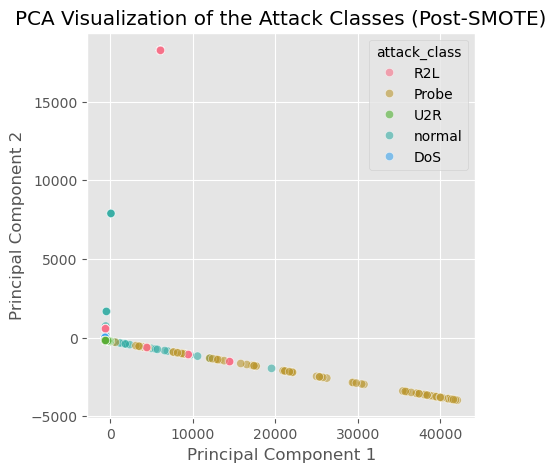

In [25]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

sample_idx = X_resampled.sample(5000, random_state=42).index

X_sample = X_resampled.loc[sample_idx]
y_sample = y_resampled.loc[sample_idx]

pca = PCA(n_components=2)
x_pca = pca.fit_transform(X_sample)

plt.figure(figsize=(5,5))
sns.scatterplot(x=x_pca[:,0], y=x_pca[:,1], hue=y_sample, alpha=0.6)
plt.title("PCA Visualization of the Attack Classes (Post-SMOTE)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

In [30]:
import os
import pandas as pd

df_final_train = pd.concat([X_resampled, y_resampled], axis=1)

output_dir = r"C:\Users\Admin\data"

os.makedirs(output_dir, exist_ok=True)

save_path = os.path.join(output_dir, "train_processed_advanced.csv")

df_final_train.to_csv(save_path, index=False)

print("File saved successfully")
print("Full path:", save_path)

File saved successfully
Full path: C:\Users\Admin\data\train_processed_advanced.csv


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import RobustScaler, OneHotEncoder, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from imblearn.over_sampling import SMOTE

In [32]:
COL_NAMES = ["duration","protocol_type","service","flag","src_bytes","dst_bytes","land","wrong_fragment","urgent","hot","num_failed_logins","logged_in","num_compromised","root_shell","su_attempted","num_root","num_file_creations","num_shells","num_access_files","num_outbound_cmds","is_host_login","is_guest_login","count","srv_count","serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate","same_srv_rate","diff_srv_rate","srv_diff_host_rate","dst_host_count","dst_host_srv_count","dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate","dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate","dst_host_rerror_rate","dst_host_srv_rerror_rate","label","difficulty_level"]

In [34]:
import os
import pandas as pd

df_final_train = pd.concat([X_resampled, y_resampled], axis=1)

output_dir = r"C:\Users\Admin\data"

os.makedirs(output_dir, exist_ok=True)

save_path = os.path.join(output_dir, "train_processed_advanced.csv")

df_final_train.to_csv(save_path, index=False)

print("Saved the Data to:")
print(save_path)

Saved the Data to:
C:\Users\Admin\data\train_processed_advanced.csv


In [35]:
df_train = pd.read_csv(r"C:\Users\Admin\data\KDDTrain+.txt", header=None, names=COL_NAMES)
df_test = pd.read_csv(r"C:\Users\Admin\data\KDDTest+.txt", header=None, names=COL_NAMES)

In [36]:
attack_mapping = {
    'normal': 'normal',
    'back': 'DoS','land': 'DoS','neptune': 'DoS','pod': 'DoS','smurf': 'DoS','teardrop': 'DoS','mailbomb': 'DoS','apache2': 'DoS','processtable': 'DoS','udpstorm': 'DoS',
    'satan': 'Probe','ipsweep': 'Probe','nmap': 'Probe','portsweep': 'Probe','mscan': 'Probe','saint': 'Probe',
    'guess_passwd': 'R2L','ftp_write': 'R2L','imap': 'R2L','phf': 'R2L','multihop': 'R2L','warezmaster': 'R2L','warezclient': 'R2L','spy': 'R2L','xlock': 'R2L','xsnoop': 'R2L','snmpguess': 'R2L','snmpgetattack': 'R2L','httptunnel': 'R2L','sendmail': 'R2L','named': 'R2L',
    'buffer_overflow': 'U2R','loadmodule': 'U2R','perl': 'U2R','rootkit': 'U2R','ps': 'U2R','xterm': 'U2R','sqlattack': 'U2R'
}

df_train['attack_class'] = df_train['label'].str.strip().map(attack_mapping)
df_test['attack_class'] = df_test['label'].str.strip().map(attack_mapping)

In [37]:
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

cols_to_encode = ['protocol_type','flag']

ohe_train = pd.DataFrame(
    ohe.fit_transform(df_train[cols_to_encode]),
    columns=ohe.get_feature_names_out(cols_to_encode),
    index=df_train.index
)

ohe_test = pd.DataFrame(
    ohe.transform(df_test[cols_to_encode]),
    columns=ohe.get_feature_names_out(cols_to_encode),
    index=df_test.index
)

service_freq = df_train['service'].value_counts(normalize=True)

df_train['service_freq'] = df_train['service'].map(service_freq)
df_test['service_freq'] = df_test['service'].map(service_freq).fillna(0)

df_train = pd.concat([df_train.drop(columns=cols_to_encode), ohe_train], axis=1)
df_test = pd.concat([df_test.drop(columns=cols_to_encode), ohe_test], axis=1)

In [38]:
exclude_cols = ['label','attack_class','difficulty_level']

numeric_cols = df_train.select_dtypes(include=['int64','float64']).columns
features_to_scale = [c for c in numeric_cols if c not in exclude_cols]

scaler = RobustScaler()

df_train[features_to_scale] = scaler.fit_transform(df_train[features_to_scale])
df_test[features_to_scale] = scaler.transform(df_test[features_to_scale])

In [39]:
X = df_train.drop(columns=['label','attack_class','difficulty_level'])
y = df_train['attack_class']

X = X.select_dtypes(include=['int64','float64']).fillna(0)

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

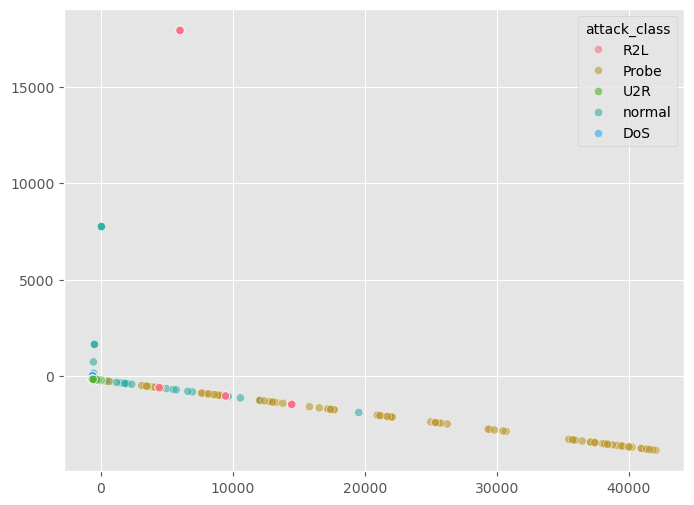

In [40]:
sample_idx = X_resampled.sample(5000, random_state=42).index

X_sample = X_resampled.loc[sample_idx]
y_sample = y_resampled.loc[sample_idx]

pca = PCA(n_components=2)
x_pca = pca.fit_transform(X_sample)

plt.figure(figsize=(8,6))
sns.scatterplot(x=x_pca[:,0], y=x_pca[:,1], hue=y_sample, alpha=0.6)
plt.show()

In [41]:
import os

df_final_train = pd.concat([X_resampled, y_resampled], axis=1)

output_dir = r"C:\Users\Admin\data"

os.makedirs(output_dir, exist_ok=True)

save_path = os.path.join(output_dir, "train_processed_advanced.csv")

df_final_train.to_csv(save_path, index=False)

print("Saved to:", save_path)

Saved to: C:\Users\Admin\data\train_processed_advanced.csv
